#SHAP FEATURE ANALYSIS


#1. Project Context
This notebook contains SHAP (SHapley Additive exPlanations) analysis
performed on the individual base learning models developed for the
classification of TESS Objects of Interest (TOIs).

The objective of this analysis is to investigate how engineered
astrophysical features contribute to model predictions and to improve
interpretability of the classification workflow.

SHAP analysis was applied independently to each base learner to:
- evaluate global feature importance
- identify dominant predictive features
- compare feature behaviour across models
- support interpretable machine learning analysis

To improve reproducibility and computational efficiency, precomputed
SHAP values were serialized and stored as `.pkl` files for reuse during
visualisation and downstream analysis.

This notebook focuses specifically on model interpretability rather than
ensemble model construction or training workflows.

#2. Declarations

In [1]:
# PYTHON LIBRARIES
import warnings # Display warning messages

warnings.filterwarnings('ignore')

import calendar                 # Convert to names of month
import csv                      # Reading in CSV files
import numpy as np              # Operations on arrays
import pandas as pd             # Data manipulation and analysis
import datetime as dt           # Date and time manipulation
import math                     # Mathematical functions
import matplotlib.pyplot as plt # Python Visualisation
import seaborn as sns           # Seaborn library
import os                       # Operating System

import matplotlib.dates as mdate # Date manipulation for graphical display

# MAGIC COMMAND TO PLOT FIGURES IN THE NOTEBOOK
%matplotlib inline

from IPython import get_ipython
get_ipython().magic('reset -sf')

In [2]:
# COMPUTE SHAP IMPORTANCE

import shap

#3. Set up GitHub Repository

In [3]:
# REMOVE OLD CLONED REPOSITORY

!rm -rf tess-ensemble-classification

In [4]:
# CLONE REPOSITORY

!git clone https://github.com/svmk-data-science/tess-ensemble-classification.git

Cloning into 'tess-ensemble-classification'...
remote: Enumerating objects: 531, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 531 (delta 45), reused 1 (delta 1), pack-reused 443 (from 1)
Receiving objects: 100% (531/531), 4.79 MiB | 25.17 MiB/s, done.
Resolving deltas: 100% (279/279), done.


In [5]:
# MOVE INTO NOTEBOOK DIRECTORY

%cd tess-ensemble-classification/notebooks

/content/tess-ensemble-classification/notebooks


#4. Load Required Files

##4.1. SHAP Values per model

Load precomputed SHAP values per Base Learner.

In [6]:
from pathlib import Path
import pandas as pd   # Data manipulation and analysis

DATA_DIR = Path("../data")

In [7]:
import joblib

# SUPPORT VECTOR CLASSIFIER (SVC)
shap_values_SVC = joblib.load(
    DATA_DIR /"shap_values_SVC.pkl"
)

# RANDOM FOREST CLASSIFIER (RF)
shap_values_RF = joblib.load(
    DATA_DIR /"shap_values_RF.pkl"
)

# LIGHT GRADIENT BOOSTING MACHINE (LightGBM)
shap_values_LGBM = joblib.load(
    DATA_DIR /"shap_values_LGBM.pkl"
)

# MULTI-LAYER PERCEPTRON NEURAL NETWORK (MLP)
shap_values_MLP = joblib.load(
    DATA_DIR /"shap_values_MLP.pkl"
)

##3.2. Test Sample

For SHAP explanation.

In [8]:
# READ SAMPLES

df_X_sample = pd.read_csv(DATA_DIR /"X_sample.csv")
df_X_sample_r = pd.read_csv(DATA_DIR /"X_sample_r.csv")

#4. SHAP Analysis



## SHAP Interpretation Overview

SHAP summary plots were generated to evaluate global feature importance
and feature behaviour across individual base learning models.

Features are ranked according to their overall contribution to model
predictions. Colour gradients indicate feature magnitude:
- red = high feature values
- blue = low feature values

Features appearing near the top of the plot exert greater influence on
model predictions.

##4.1. Support Vector Classifier (SVC)

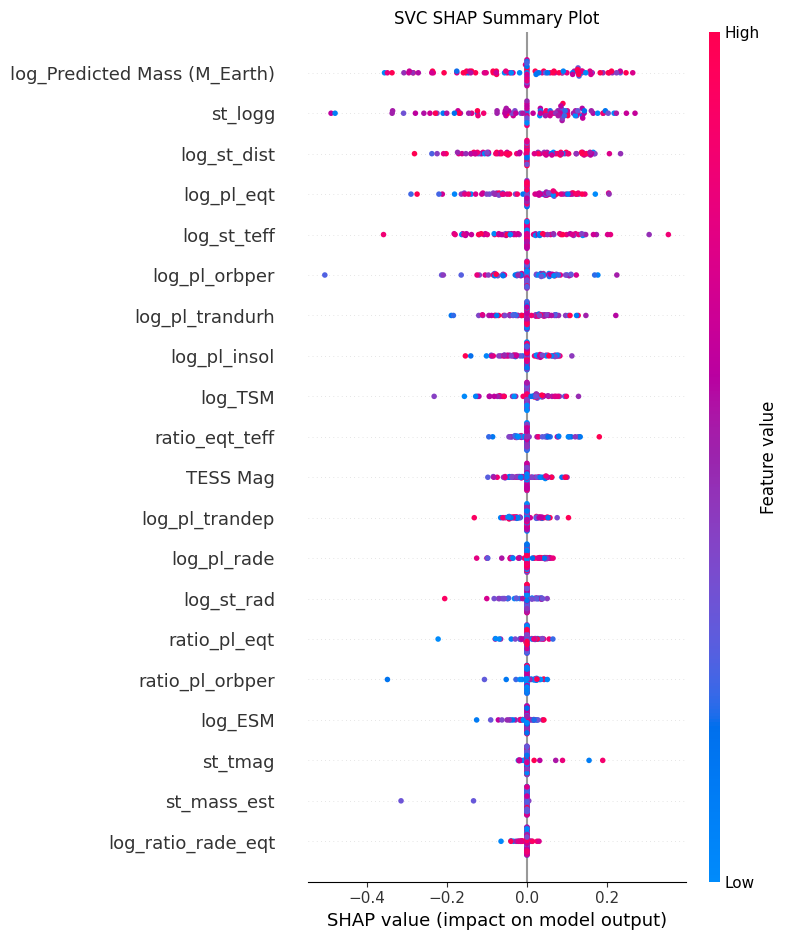

In [9]:
# 📊 Summary Plot: global feature importance
import matplotlib.pyplot as plt

plt.title("SVC SHAP Summary Plot")
shap.summary_plot(shap_values_SVC, df_X_sample, feature_names= df_X_sample.columns)

### Interpretation

The SVC SHAP summary plot demonstrates that multiple astrophysical features contribute meaningfully to classification outcomes. The spread of SHAP values suggests that the model captures non-linear relationships across the feature space.

##4.2. Random Forest Classifier (RF)

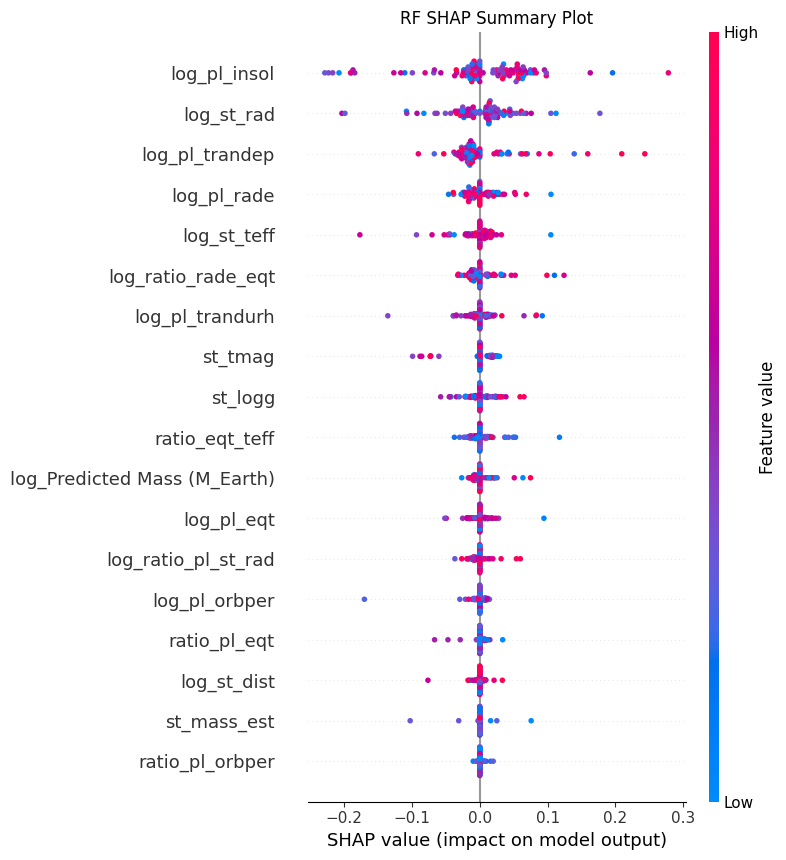

In [10]:
# 📊 Summary Plot: global feature importance

plt.title("RF SHAP Summary Plot")
shap.summary_plot(shap_values_RF, df_X_sample_r, feature_names= df_X_sample_r.columns)

### Interpretation

The Random Forest SHAP summary plot highlights the most influential features contributing to ensemble tree-based decision making.

A smaller subset of dominant features appears to drive a significant portion of the model predictions, consistent with the hierarchical split
structure of Random Forest classifiers.

The reduced number of features retained strong predictive influence,
suggesting that SHAP-guided feature selection preserved important classification information while reducing dimensionality.

The resulting concentration of SHAP importance may indicate effective feature prioritisation within the reduced feature space.

##4.3. Light Gradient Boosting Machine (LightGBM)

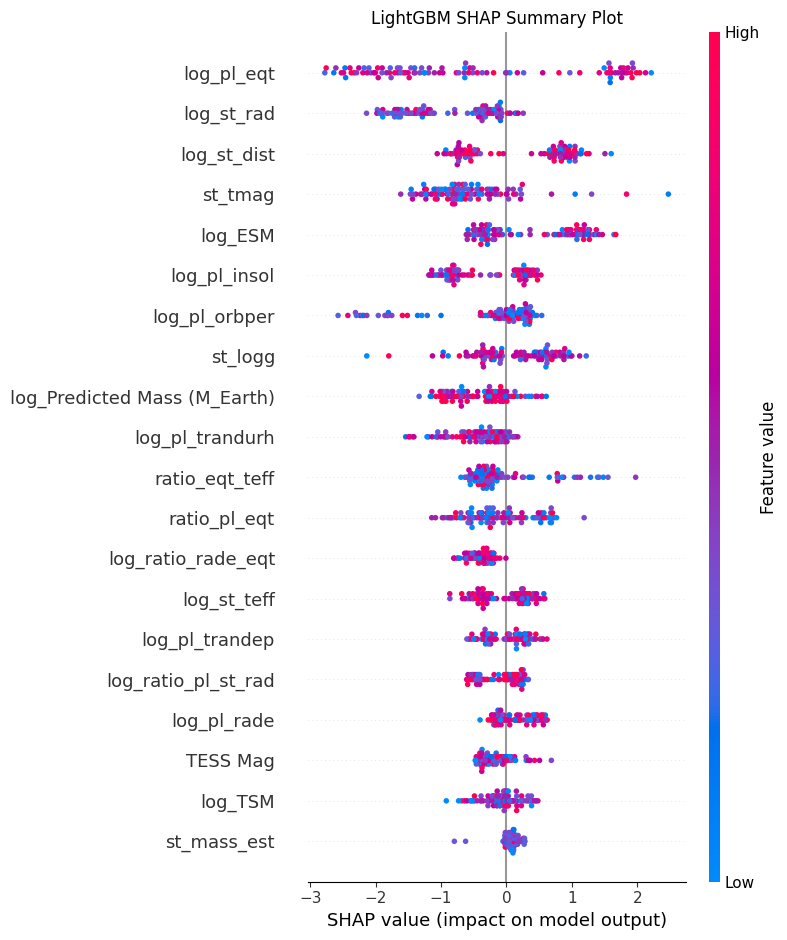

In [11]:
# 📊 Summary Plot: global feature importance

plt.title("LightGBM SHAP Summary Plot")
shap.summary_plot(shap_values_LGBM, df_X_sample, feature_names= df_X_sample.columns)

### Interpretation

The LightGBM SHAP summary plot demonstrates strong feature sensitivity
within the gradient boosting framework.

Several dominant features exert substantial influence on prediction
outcomes, while lower-ranked features contribute more modestly to model
behaviour.

The wider SHAP value dispersion observed for highly ranked features may
indicate that LightGBM captures complex non-linear feature interactions
and varying decision boundaries across the dataset.

Compared with other base learners, LightGBM exhibits greater feature
importance due to its boosting-based optimisation process.

##4.4. Multi-Layer Perceptron Neural Network (MLP)

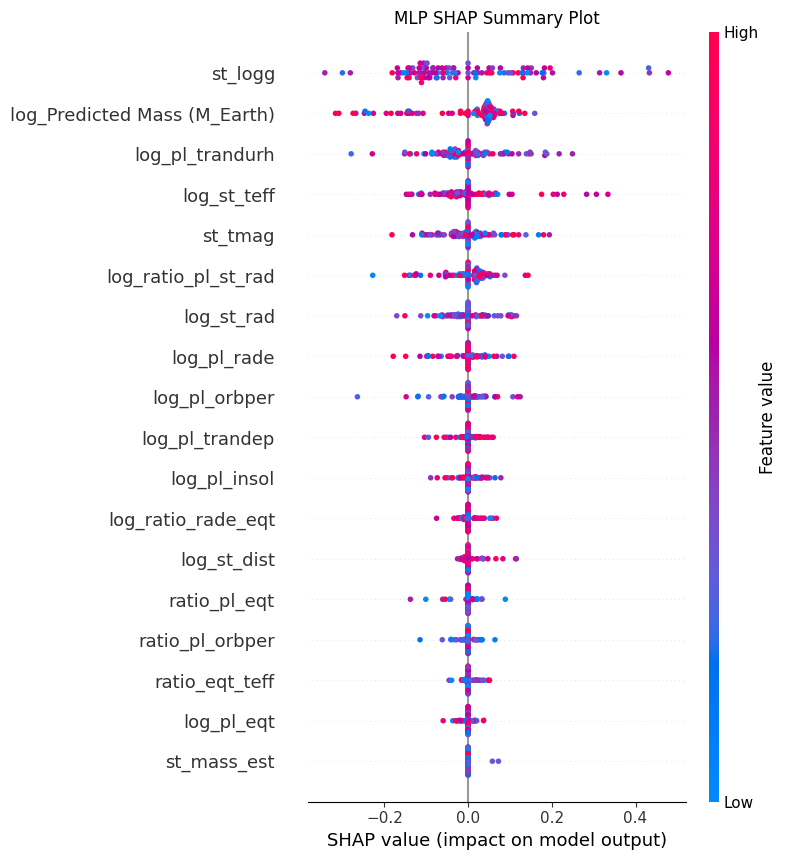

In [12]:
# 📊 Summary Plot: global feature importance

plt.title("MLP SHAP Summary Plot")
shap.summary_plot(shap_values_MLP, df_X_sample_r, feature_names= df_X_sample_r.columns)

### Interpretation

The MLP SHAP summary plot demonstrates distribution of the predictive influence across multiple interacting features.

Unlike tree-based models, the MLP may exhibit a more diffuse feature importance profile, reflecting the distributed representation learning
behaviour characteristic of neural networks.

The reduced feature set appears sufficient to preserve meaningful predictive structure while supporting improved interpretability and reduced model complexity.

#5. Comparative SHAP Analysis

SHAP analysis demonstrated that several engineered astrophysical
features consistently contributed to predictive performance across
multiple base learners.

Tree-based models such as Random Forest and LightGBM possessed a smaller subset of dominant predictors contributing heavily to classification outcomes.The reduced SHAP-selected feature space preserved substantial predictive
information while improving interpretability and reducing feature
complexity.

In contrast, the SVC and MLP models displayed greater distributed feature
importance patterns, suggesting that these models relied on broader
feature interactions and non-linear relationships.

Overall, the SHAP analysis supported the interpretability of the
ensemble modelling workflow and provided insight into how different base
learners responded to astrophysical feature variations.

#6. Cross-Model SHAP Feature Consistency

The following table summarises the dominant SHAP-ranked features
identified across the individual base learning models.

In [13]:
import pandas as pd

# CREATE FEATURE COMPARISON TABLE
feature_table = pd.DataFrame({
    "Feature": [
        "log_predicted Mass (M_Earth)",
        "st_logg",
        "log_st_dist",
        "log_pl_eqt",
        "log_st_teff",
        "log_st_rad",
        "log_ratio_rade_eqt",
        "log_pl_trandurh",
        "st_tmag"
    ],

    "SVC": ["✓", "✓", "✓", "✓", "✓", "", "", "", ""],

    "RF": ["", "", "", "", "✓", "✓", "✓", "✓", "✓"],

    "LightGBM": ["", "", "✓", "✓", "✓", "✓", "", "", "✓"],

    "MLP": ["✓", "✓", "", "", "✓", "", "", "✓", "✓"]
})

# DISPLAY TABLE
feature_table

,Feature,SVC,RF,LightGBM,MLP
0,log_predicted Mass (M_Earth),✓,,,✓
1,st_logg,✓,,,✓
2,log_st_dist,✓,,✓,
3,log_pl_eqt,✓,,✓,
4,log_st_teff,✓,✓,✓,✓
5,log_st_rad,,✓,✓,
6,log_ratio_rade_eqt,,✓,,
7,log_pl_trandurh,,✓,,✓
8,st_tmag,,✓,✓,✓


Comparison of SHAP summary plots revealed several features that
consistently contributed to predictive behaviour across multiple base
learners.

In particular, `log_st_teff` appeared among the highest-ranked features
for all models, indicating robust predictive importance independent of
model architecture.

Additional features demonstrating substantial cross-model agreement
included:
- `st_tmag`
- `log_st_dist`
- `log_pl_eqt`
- `log_st_rad`

Tree-based learners (Random Forest and LightGBM) exhibited stronger
agreement in feature prioritisation, while the SVC and MLP models
displayed more distributed importance profiles.

The consistency of several dominant features across heterogeneous
learners supports the validity of the reduced SHAP-selected feature
space used throughout the ensemble modelling workflow.